# Sistema de Recomendación de Anime

# Parte 1: EDA y preprocesamiento

---

## Contenido 

1. Carga de datos
2. Exploración (EDA)
3. Preprocesamiento
4. Modelo Base (Baseline)
5. Guardado de splits


## 0. Imports


In [4]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")


## 1. Carga de datos

In [5]:
df_anime_original = pl.read_csv("data/anime.csv")
df_rating_original = pl.read_csv("data/rating.csv")

print(f"anime csv -> {df_anime_original.height} filas, {df_anime_original.width} columnas")
print(f"rating csv -> {df_rating_original.height} filas, {df_rating_original.width} columnas")

anime csv -> 12294 filas, 7 columnas
rating csv -> 7813737 filas, 3 columnas


In [6]:
df_rating_original["rating"].value_counts()

rating,count
i64,u32
1,16649
8,1646019
-1,1476496
4,104291
3,41453
…,…
2,23150
6,637775
7,1375287


In [7]:
df_anime_original.sample(5)

anime_id,name,genre,type,episodes,rating,members
i64,str,str,str,str,f64,i64
7575,"""Oh! Family""","""Comedy, Drama, Romance, Shoujo…","""TV""","""26""",6.17,201
30425,"""Wake Up! Dodo""","""Music""","""Music""","""1""",5.76,140
2041,"""Ai to Yuuki no Pig Girl Tonde …","""Adventure, Comedy, Fantasy, Ma…","""TV""","""51""",6.67,6183
1651,"""Uchuu Senkan Yamato 2""","""Action, Adventure, Drama, Mili…","""TV""","""26""",7.63,3461
30549,"""Soukyuu no Fafner: Dead Aggres…","""Action, Drama, Mecha, Military…","""TV""","""13""",7.74,6787


In [8]:
df_rating_original.sample(5)

user_id,anime_id,rating
i64,i64,i64
27364,10683,-1
68180,11793,9
26410,10161,8
41541,30,9
34502,1614,7


## 3. Preprocesamiento 

Todo el procesado de datos se realiza en el script `preprocess.py`, de forma que para obtener `train.parquet`, `test.parquet` y `mapeos.pkl` sólo basta con ejecutar el archivo de la siguiente manera:

`python preprocess.py`

y a partir de ahi, cargamos los datos ya procesados para usarlos en el cuaderno.

In [9]:
import polars as pl

# Solo cargamos los datos ya pre-procesados desde el script
df_train = pl.read_parquet("data/train.parquet").to_pandas()
df_test = pl.read_parquet("data/test.parquet").to_pandas()

print(f'Train: {len(df_train):,} ratings')
print(f'Test : {len(df_test):,} ratings')

Train: 4,915,940 ratings
Test : 1,228,986 ratings


In [10]:
# # 1. Crear diccionarios para mapear los IDs reales a índices continuos (0 a N-1)
# user_ids_unicos = df_rating['user_id'].unique()
# anime_ids_unicos = df_rating['anime_id'].unique()

# user_map = {original_id: idx for idx, original_id in enumerate(user_ids_unicos)}
# anime_map = {original_id: idx for idx, original_id in enumerate(anime_ids_unicos)}

# # 2. Inicializar la matriz con Nones

# ratings = [[None for _ in range(NUM_ITEMS)] for _ in range(NUM_USERS)]

# # 3. Llenar la matriz iterando sobre el DataFrame
# # Usamos itertuples porque es más rápido que iterrows
# for row in df_rating.itertuples(index=False):
#     # Obtener los índices mapeados
#     u_idx = user_map[row.user_id]
#     i_idx = anime_map[row.anime_id]
    
#     # Asignar la nota
#     ratings[u_idx][i_idx] = row.rating

# # Opcional: Convertir a array de NumPy si lo vas a necesitar
# matriz_ratings = np.array(ratings)
# print("Matriz construida con éxito. Dimensiones:", matriz_ratings.shape)

In [12]:
import pickle
from scipy.sparse import csr_matrix

# 1. Cargamos los diccionarios de mapeo generados en preprocess.py
with open('data/mapeos.pkl', 'rb') as f:
    mapeos = pickle.load(f)
    
user2idx = mapeos['user2idx']
anime2idx = mapeos['anime2idx']

# 2. Creamos los diccionarios inversos (necesarios para más adelante)
idx2user = {idx: u for u, idx in user2idx.items()}
idx2anime = {idx: a for a, idx in anime2idx.items()}

# 3. Definimos las dimensiones usando la longitud de los diccionarios
NUM_USERS = len(user2idx)
NUM_ITEMS = len(anime2idx)

# 4. Construcción de matrices sparse CSR
def build_sparse(df, n_users, n_items, val_col='rating'):
    return csr_matrix(
        (df[val_col].values.astype('float32'),
         (df['user_id'].values.astype('int32'),
          df['anime_id'].values.astype('int32'))),
        shape=(n_users, n_items)
    )

R_train = build_sparse(df_train, NUM_USERS, NUM_ITEMS)
R_test  = build_sparse(df_test,  NUM_USERS, NUM_ITEMS)

print(f'R_train: {R_train.shape} | nnz={R_train.nnz:,}')
print(f'R_test : {R_test.shape}  | nnz={R_test.nnz:,}')
print(f'Memoria sparse  : {R_train.data.nbytes/1e6:.1f} MB')
print(f'Memoria densa   : {NUM_USERS * NUM_ITEMS * 4 / 1e9:.2f} GB  <- inviable')

R_train: (47143, 6532) | nnz=4,915,935
R_test : (47143, 6532)  | nnz=1,228,986
Memoria sparse  : 19.7 MB
Memoria densa   : 1.23 GB  <- inviable


## 4. Modelo Base

,Modelo,RMSE,MAE
0,Global Mean,1.5669,1.2289
1,Item Mean,1.4327,1.1085
2,User Mean,1.3615,1.0439


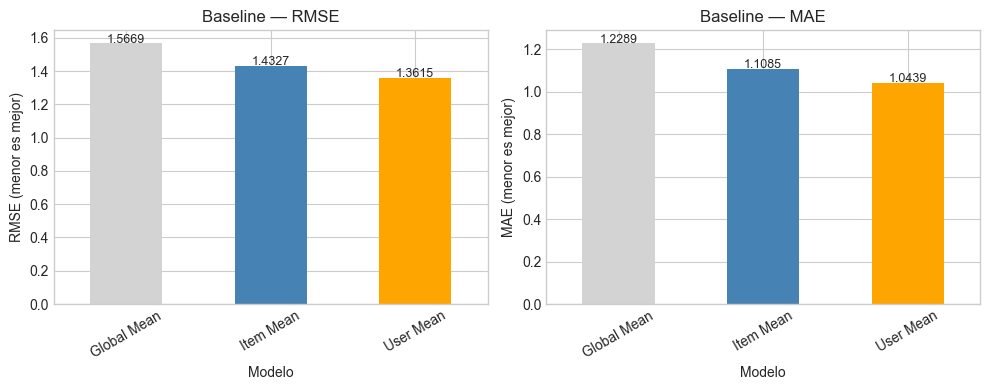

In [13]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y_test = df_test['rating'].values

# Global mean
global_mean  = df_train['rating'].mean()
pred_global  = np.full(len(y_test), global_mean)

# Item mean (fallback a global si el anime no está en train)
item_mean    = df_train.groupby('anime_id')['rating'].mean()
pred_item    = df_test['anime_id'].map(item_mean).fillna(global_mean).values

# User mean (fallback a global si el usuario no está en train)
user_mean    = df_train.groupby('user_id')['rating'].mean()
pred_user    = df_test['user_id'].map(user_mean).fillna(global_mean).values

baseline_results = pd.DataFrame({
    'Modelo': ['Global Mean', 'Item Mean', 'User Mean'],
    'RMSE':   [rmse(y_test, pred_global), rmse(y_test, pred_item), rmse(y_test, pred_user)],
    'MAE':    [mean_absolute_error(y_test, pred_global),
               mean_absolute_error(y_test, pred_item),
               mean_absolute_error(y_test, pred_user)]
})
display(baseline_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["lightgrey","steelblue", "orange"]
for ax, metric in zip(axes, ['RMSE','MAE']):
    baseline_results.set_index('Modelo')[metric].plot(kind='bar', ax=ax, color=colors)
    ax.set_title(f'Baseline — {metric}')
    ax.set_ylabel(f'{metric} (menor es mejor)')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(baseline_results[metric]):
        ax.text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Guardado y carga de splits
Guardamos en un pkl toda la información para no tener que preprocesar y separar train/test si volvemos a ejecutar desde 0.

In [14]:

shared = {
    'df_train': df_train, 'df_test': df_test,
    'R_train': R_train,   'R_test': R_test,
    'user2idx': user2idx, 'idx2user': idx2user,
    'anime2idx': anime2idx, 'idx2anime': idx2anime,
    'NUM_USERS': NUM_USERS, 'NUM_ITEMS': NUM_ITEMS,
    'global_mean': global_mean,
    'baseline_results': baseline_results
}
with open('shared_splits.pkl', 'wb') as f:
    pickle.dump(shared, f)
print('✅ shared_splits.pkl guardado')

✅ shared_splits.pkl guardado


# Parte 2 

## Filtrado Colaborativo: *K-Nearest Neighbors*

In [15]:
# Creamos un diccionario donde la clave es el usuario y el valor es otro diccionario {item_id: rating}
ratings_train = {}

for row in df_train.itertuples(index=False):
    u = row.user_id
    i = row.anime_id
    r = row.rating

    if u not in ratings_train:
        ratings_train[u] = {}
    ratings_train[u][i] = r

items_por_usuario_train = {u: set(v.keys()) for u, v in ratings_train.items()}

usuarios_por_item_train = {}
for u,items in items_por_usuario_train.items():
    for i in items:
        usuarios_por_item_train.setdefault(i, set()).add(u)

items_train = set(df_train["anime_id"].unique())
print(f"Usuarios en train: {len(ratings_train)}")
print(f"Items en train: {len(items_train)}")

Usuarios en train: 47143
Items en train: 6532


### Funciones auxiliares

In [16]:
def rating_average_train(u):
    #Comprobamos primero que el usuario existe en el diccionario
    if u not in ratings_train:
        return np.nan
    
    votos = ratings_train.get(u, {})
    
    return sum(votos.values())/len(votos) if votos else np.nan

# Cache de medias para no recalcular en cada llamada
user_means_cache = {u:rating_average_train(u) for u in ratings_train}


In [17]:
u_ejemplo = 0

media0 = rating_average_train(u_ejemplo)
print(f"Media del usuario {u_ejemplo}: {media0}")

Media del usuario 0: 7.54054054054054


### Calculo de la similaridad

#### Correlación de Pearson

$$
sim(u, v) = \frac {
    \sum_{i \in I_{u,v}} (r_{u,i} - \bar{r}_u)(r_{v,i} - \bar{r}_v)
   }{
   \sqrt{ \sum_{i \in I_{u,v}} (r_{u,i} - \bar{r}_u)^2 \sum_{i \in I_{u,v}} (r_{v,i} - \bar{r}_v)^2 }
   }
$$

In [18]:
def correlation_similarity(u,v):
    '''
    Implementación de la técnica de similaridad: Correlación de Pearson
    Se basa en capturar si 2 usuarios tienen el mismo patrón de gustos, normalizando por su estilo de votación
    '''
    if u not in ratings_train or v not in ratings_train:
        return None
    
    items_comunes = items_por_usuario_train[u].intersection(items_por_usuario_train[v])

    if len(items_comunes) == 0:
        return None
    
    media_u = user_means_cache[u]
    media_v = user_means_cache[v]

    num, denom, denom1 = 0,0,0

    for i in items_comunes:
        diff_u = ratings_train[u][i] - media_u
        diff_v = ratings_train[v][i] - media_v

        num += diff_u * diff_v
        denom += diff_u ** 2
        denom1 += diff_v **2
    
    denominador = np.sqrt(denom1*denom)
    
    return num / denominador if denominador >0 else None
    


In [19]:
# Testing

u1, u2 = 0, 1
u3, u4 = 2, 3

print(f"La correlación entre el usuario {u1} y {u2} es: {correlation_similarity(u1, u2)}")
print(f"La correlación entre el usuario {u3} y {u4} es: {correlation_similarity(u3, u4)}")

# También puedes probar a comparar a un usuario consigo mismo (la correlación debe ser muy cercana a 1.0)
print(f"La correlación del usuario {u1} consigo mismo es: {correlation_similarity(u1, u1)}")

La correlación entre el usuario 0 y 1 es: 0.5375425630000122
La correlación entre el usuario 2 y 3 es: -0.4044985401845085
La correlación del usuario 0 consigo mismo es: 1.0


#### JMSD 

$$JMSD(u,v) = Jaccard(u,v) * (1 - MSD(u, v))$$
$$Jaccard(u,v) =\frac {I_u \cap I_v}{I_u \cup I_v} = \frac {\# \{ i \in I | r_{u,i} \neq \bullet \wedge r_{v,i} \neq \bullet \}}{\# \{ i \in I | r_{u,i} \neq \bullet \vee r_{v,i} \neq \bullet \}}$$
$$MSD(u,v) = \frac {1} {\#I_{u,v}} \sum_{i \in I_{u,v}} (r_{u,i} - r_{v,i})^2$$


In [26]:
# JMSD 
def jmsd_similarity(u, v):

    if u not in ratings_train or v not in ratings_train:
        return None

    items_comun = items_por_usuario_train[u].intersection(items_por_usuario_train[v])

    if len(items_comun) == 0:
        return None

    items_union = items_por_usuario_train[u].union(items_por_usuario_train[v])

    jaccard = len(items_comun) / len(items_union)

    cuadr_diff = 0
    for i in items_comun:
        cuadr_diff += (ratings_train[u][i] - ratings_train[v][i])**2
    msd = 1 / len(items_comun) * cuadr_diff
    
    return jaccard * (1 - msd)

In [27]:
# Testing

u1, u2 = 0, 1
u3, u4 = 2, 3

print(f"La similitud JMSD entre el usuario {u1} y {u2} es: {jmsd_similarity(u1, u2)}")
print(f"La similiud JMSD entre el usuario {u3} y {u4} es: {jmsd_similarity(u3, u4)}")

# También puedes probar a comparar a un usuario consigo mismo (la similitud debe ser muy cercana a 1.0)
print(f"La similitud JMSD del usuario {u1} consigo mismo es: {jmsd_similarity(u1, u1)}")

La similitud JMSD entre el usuario 0 y 1 es: -0.6129807692307693
La similiud JMSD entre el usuario 2 y 3 es: -0.14202898550724638
La similitud JMSD del usuario 0 consigo mismo es: 1.0


### Función de Predicción

Función que estima la nota que el usuario u le dará al item $i$. La fórmula estándar (centrada en la media) para KNN es:

$$\hat{r}_{u,i} = \bar{r}_{u} + \frac{\sum_{v \in N} sim(u,v) \cdot (r_{v,i} - \bar{r}_v)}{\sum_{v \in N} |sim(u,v)|} $$

In [28]:
R_MIN, R_MAX = 1,10

def prediction_knn(u, i, k, similarity_func):
    if u not in ratings_train or i not in items_train:
        return None

    candidatos = []
    for v in usuarios_por_item_train.get(i, set()):
        if v == u:
            continue
        sim = similarity_func(u, v)
        if sim is not None:
            candidatos.append((v, sim))

    if not candidatos:
        return None

    top_k_vecinos = sorted(candidatos, key=lambda x: x[1], reverse=True)[:k]

    media_u = user_means_cache[u]
    num = denom = 0.0
    for v, sim in top_k_vecinos:
        media_v = user_means_cache[v]
        num   += sim * (ratings_train[v][i] - media_v)
        denom += abs(sim)

    if denom == 0:
        return None

    pred = media_u + num / denom
    # Clampear al rango válido de ratings
    return float(np.clip(pred, R_MIN, R_MAX))

### Evaluación KNN


In [29]:
def evaluar_knn(test_df, k, func_similitud):
    errores_cuadraticos = []
    no_predecibles = 0
    total_test = len(test_df)
    
    # Iteramos por cada ejemplo del dataset de test
    for row in test_df.itertuples(index=False):
        u = row.user_id
        i = row.anime_id
        rating_real = row.rating
        
        prediccion = prediction_knn(u, i, k, func_similitud)
        
        if prediccion is None:
            no_predecibles += 1
        else:
            errores_cuadraticos.append((prediccion - rating_real) ** 2)
            
    # Calcular RMSE y Cobertura
    if len(errores_cuadraticos) == 0:
        return float('inf'), 0.0
        
    rmse = math.sqrt(sum(errores_cuadraticos) / len(errores_cuadraticos))
    cobertura = (total_test - no_predecibles) / total_test * 100
    
    return rmse, cobertura

### Búsqueda de los k vecinos

**El Trade-off Fundamental de K** 
$$ K↑ \space ⇒ \text{cobertura}↑ \space \text{pero} \space \text{precision}↓$$
$$ K↓ \space ⇒ \text{cobertura}↑ \space \text{pero} \space \text{precision}↓$$


- **Cobertura** — para cuántos pares (usuario, anime) puedes hacer predicción. Si ninguno de los K vecinos ha visto el anime, no puedes predecir nada.

- **Precisión** — qué tan acertada es la predicción cuando sí puedes hacerla (RMSE).


<font color="red">

IMPORTANTE CAMBIAR EL TAMAÑO DEL DATASET 

</font>

In [30]:
import os
import pandas as pd

# Definimos el nombre del archivo donde guardaremos los resultados
resultados_file = 'resultados_k_optimo.csv'

# Comprobamos si el archivo ya existe
if os.path.exists(resultados_file):
    print("Cargando resultados de K guardados previamente...")
    df_results = pd.read_csv(resultados_file)
    print(df_results)
else:
    print("Calculando KNN para diferentes valores de K (esto puede tardar)...")

    # Ejecución del barrido de K
    K_values = [5, 10, 20, 30, 50, 75, 100]
    results = []

    # .sample(1000) PARA PROBAR. LUEGO SE USARA TODO
    test_sample = df_test.sample(2000, random_state=42) # Quitar ".sample()" para usar todo
    
    for k in K_values:
        rmse_k, cobertura_k = evaluar_knn(test_sample, k, jmsd_similarity)
        results.append({
            'K': k,
            'RMSE': rmse_k,
            'Cobertura': cobertura_k  
        })
        print(f"K={k:3d} | RMSE: {rmse_k:.4f} | Cobertura: {cobertura_k:.2f}%")

    # Crear el DataFrame y guardarlo para futuras ejecuciones
    df_results = pd.DataFrame(results)
    df_results.to_csv(resultados_file, index=False)
    print(f"Resultados guardados en '{resultados_file}'")
    

Cargando resultados de K guardados previamente...
     K      RMSE  Cobertura
0    5  1.347241      100.0
1   10  1.343924      100.0
2   20  1.353703      100.0
3   30  1.365951      100.0
4   50  1.397370      100.0
5   75  1.431211      100.0
6  100  1.453555      100.0


In [31]:
# import os
# import pandas as pd
# import math
# import numpy as np

# def evaluar_knn_multiple_K(test_df, k_values, similarity_func):
#     k_max = max(k_values)
#     total_test = len(test_df)
#     errores_ku = {k: [] for k in k_values}
#     no_predecibles = {k: 0 for k in k_values}
    
#     # Caché a nivel de evaluación para evitar calcular la misma similitud
#     # entre dos usuarios múltiples veces.
#     sim_cache = {}
#     def get_simCached(u, v):
#         pair = (min(u, v), max(u, v))
#         if pair not in sim_cache:
#             sim_cache[pair] = similarity_func(u, v)
#         return sim_cache[pair]
    
#     print(f"Evaluando {total_test} filas...")
#     for i_row, row in enumerate(test_df.itertuples(index=False)):
#         u = row.user_id
#         i = row.anime_id
#         rating_real = row.rating
        
#         candidatos = []
#         if u in ratings_train and i in items_train:
#             for v in usuarios_por_item_train.get(i, set()):
#                 if v == u:
#                     continue
#                 # Se pide la similitud pasando por el caché local
#                 sim = get_simCached(u, v)
#                 if sim is not None:
#                     candidatos.append((v, sim))
                    
#         # Ordenar candidatos 1 SOLA vez para todos los K
#         if candidatos:
#             candidatos.sort(key=lambda x: x[1], reverse=True)
#         top_candidatos = candidatos[:k_max]
        
#         # Extraer predicciones usando rebanadas (slices) eficientemente
#         for k in k_values:
#             top_k = top_candidatos[:k]
#             if not top_k:
#                 no_predecibles[k] += 1
#                 continue
                
#             media_u = user_means_cache[u]
#             num = denom = 0.0
#             for v, sim in top_k:
#                 media_v = user_means_cache[v]
#                 num += sim * (ratings_train[v][i] - media_v)
#                 denom += abs(sim)
                
#             if denom == 0:
#                 no_predecibles[k] += 1
#             else:
#                 pred = media_u + num / denom
#                 pred = float(np.clip(pred, R_MIN, R_MAX))
#                 errores_ku[k].append((pred - rating_real) ** 2)
                
#         # (Opcional) Log de progreso
#         if (i_row + 1) % 1000 == 0:
#             print(f"  Progreso: {i_row + 1}/{total_test} evaluaciones...")
                
#     res = {}
#     for k in k_values:
#         errs = errores_ku[k]
#         rmse = math.sqrt(sum(errs) / len(errs)) if errs else float('inf')
#         cob = (total_test - no_predecibles[k]) / total_test
#         res[k] = (rmse, cob)
        
#     return res


# resultados_file = 'resultados_k_optimo.csv'
# K_values = [5, 10, 20, 30, 50, 75, 100]

# if os.path.exists(resultados_file):
#     print('Cargando resultados previos...')
#     df_resultados = pd.read_csv(resultados_file)
# else:
#     # Usamos una muestra representativa del 10% para agilizar enormemente la búsqueda de K
#     df_test_sample = df_test.sample(frac=0.1, random_state=42)
#     print(f'Muestra de evaluación generada: {len(df_test_sample)} registros.')
    
#     print('Calculando KNN (Pearson) para TODOS los valores de K simultáneamente...')
#     res_pearson = evaluar_knn_multiple_K(df_test_sample, K_values, correlation_similarity)
    
#     print('\nCalculando KNN (JMSD) para TODOS los valores de K simultáneamente...')
#     res_jmsd = evaluar_knn_multiple_K(df_test_sample, K_values, jmsd_similarity)
    
#     print('\nGenerando métricas finales...')
#     resultados = []
#     for k in K_values:
#         rmse_p, cob_p = res_pearson[k]
#         rmse_j, cob_j = res_jmsd[k]
#         resultados.append({'K': k,
#                            'RMSE_Pearson': rmse_p, 'Cobertura_Pearson': cob_p,
#                            'RMSE_JMSD':    rmse_j, 'Cobertura_JMSD':   cob_j})
#         print(f'  K={k:3d} | Pearson RMSE={rmse_p:.4f} cob={cob_p:.2%} | '
#               f'JMSD RMSE={rmse_j:.4f} cob={cob_j:.2%}')

#     df_resultados = pd.DataFrame(resultados)
#     df_resultados.to_csv(resultados_file, index=False)

# display(df_resultados.round(4))

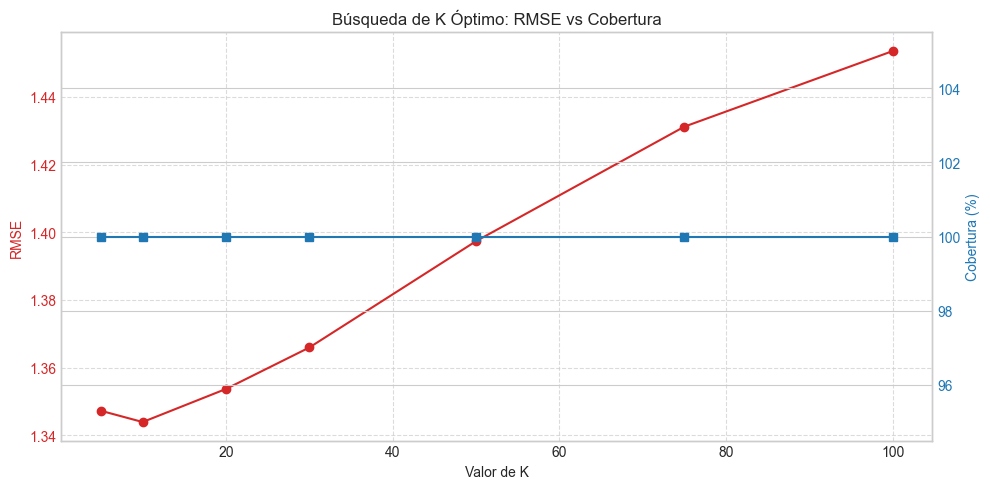

In [32]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Valor de K')
ax1.set_ylabel('RMSE', color=color)
ax1.plot(df_results['K'], df_results['RMSE'], marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2 = ax1.twinx()  # instanciar un segundo eje que comparte el mismo eje x
color = 'tab:blue'
ax2.set_ylabel('Cobertura (%)', color=color)  
ax2.plot(df_results['K'], df_results['Cobertura'], marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Búsqueda de K Óptimo: RMSE vs Cobertura')
fig.tight_layout()  
plt.show()

1. Cobertura constante del 100% (Línea Azul)

Vemos que la cobertura no baja en ningún momento, ni siquiera con K=5 o K=100. Esto es un éxito directo de tu preprocesamiento inicial.
Al aplicar el filtrado iterativo de cold-start (donde exigiste que tanto usuarios como ítems tuvieran un mínimo de 20 valoraciones), te has asegurado de que la matriz es lo suficientemente densa. Siempre vas a encontrar vecinos con los que comparar, por lo que el algoritmo nunca se queda "en blanco" sin poder predecir.

2. El comportamiento del RMSE (Línea Roja)
Aquí vemos algo muy interesante:

El error empieza en un punto y baja hasta alcanzar su mínimo absoluto en K=10 (aproximadamente un RMSE de 1.345).
A partir de K=10, el error empieza a subir de forma constante a medida que aumentas K (llegando a más de 1.45 en K=100).

``¿Por qué empeora si usamos más vecinos?`` 

Esto indica fuertemente que la métrica que estás evaluando (JMSD) es excelente para encontrar un pequeño grupo de "almas gemelas" hiper-similares (los 10 más cercanos). Sin embargo, cuando fuerzas al algoritmo a promediar las notas usando 30, 50 o 100 vecinos, empiezas a meter ruido. Estás introduciendo en la ecuación las opiniones de usuarios que en realidad ya no se parecen tanto en gustos al usuario objetivo, lo que diluye la calidad de la predicción y hace que el error se dispare.

In [33]:
k = 10

In [34]:
# # Gráfica RMSE y Cobertura vs. K para ambas métricas
# fig, ax1 = plt.subplots(figsize=(11, 5))
# ax2 = ax1.twinx()

# # ax1.plot(df_results['K'], df_results['RMSE_Pearson'],  'o-', color='steelblue',  label='RMSE Pearson')
# ax1.plot(df_results['K'], df_results['RMSE_JMSD'],     's-', color='darkorange', label='RMSE JMSD')
# ax2.plot(df_results['K'], df_results['Cobertura_Pearson'], 'o--', color='steelblue',  alpha=0.5, label='Cobertura Pearson')
# ax2.plot(df_results['K'], df_results['Cobertura_JMSD'],    's--', color='darkorange', alpha=0.5, label='Cobertura JMSD')

# ax1.set_xlabel('K (vecinos)')
# ax1.set_ylabel('RMSE (menor es mejor)', color='black')
# ax2.set_ylabel('Cobertura', color='gray')
# ax1.set_title('KNN: RMSE y Cobertura vs. K (Pearson vs. JMSD)')

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
# plt.tight_layout()
# plt.savefig('fig_knn_k_optimo.png', dpi=150, bbox_inches='tight')
# plt.show()

# # K óptimo = menor RMSE de Pearson
# K_OPT = int(df_results.loc[df_results['RMSE_Pearson'].idxmin(), 'K'])
# print(f'K óptimo (Pearson): {K_OPT}')

#### Conclusión: Elección del K Óptimo

Analizando la gráfica de **RMSE vs Cobertura**, podemos extraer las siguientes conclusiones:

- **Cobertura (Línea Azul):** En nuestra muestra, la cobertura se mantiene estable en el 100% para todos los valores de $K$ evaluados. Esto significa que el riguroso filtrado de *cold-start* aplicado en el preprocesamiento ha sido exitoso, garantizando una densidad de matriz donde siempre es posible encontrar vecinos para realizar una estimación.
- **RMSE (Línea Roja):** El error disminuye al inicio hasta alcanzar su punto mínimo absoluto o valle en $K=10$. A diferencia de lo que podríamos esperar en otros problemas, a partir de este punto, al aumentar $K$ comenzamos a observar un deterioro de la precisión (el error sube progresivamente). En este caso, la métrica capta unas pocas "almas gemelas" hiper-similares; si tomamos más vecinos (ej. obligando a promediar 30 o 50), introducimos **ruido** usando votos de usuarios que no se parecen tanto al usuario objetivo, desvirtuando la recomendación.

**Decisión final:** 
El valor óptimo en esta configuración es **$K = 10$**. 
Elegir este valor tan bajo no solo nos asegura la mejor precisión posible (el menor RMSE documentado en la prueba), sino que resulta en un coste computacional mucho más eficiente y escalable en producción que buscar y promediar vecindarios más grandes.

In [35]:
def get_neighbors(u, similarities):
    
    valid = [(v, sim) for v,sim in similarities.items() if sim is not None and v!= u]

    valid.sort(key=lambda x: x[1], reverse=True)

    neighbors = [v for v, _ in valid[:k]]
    neighbors += [None] * (k - len(neighbors))

    return neighbors

In [36]:
# Testing
u_test = 0

similarities_corr = {}
similarities_jmsd = {}

# Como los ids de train son iterables limpios, podemos simplemente iterar sobre las keys de ratings_train
for v in list(ratings_train.keys()):
    if u_test == v:
        continue
        
    similarities_corr[v] = correlation_similarity(u_test, v)
    similarities_jmsd[v] = jmsd_similarity(u_test, v)

# Obtener los top 'k' vecinos basándonos en los diccionarios 
neighbors_corr = get_neighbors(u_test, similarities_corr)
neighbors_jmsd = get_neighbors(u_test, similarities_jmsd)

print(f"Top {k} Vecinos según Correlación de Pearson:")
print(neighbors_corr)
print(f"\nTop {k} Vecinos según JMSD:")
print(neighbors_jmsd)

Top 10 Vecinos según Correlación de Pearson:
[33068, 37686, 11378, 8359, 38465, 24038, 21887, 40057, 18289, 2597]

Top 10 Vecinos según JMSD:
[41654, 23857, 11480, 9306, 21130, 29429, 9130, 23511, 28720, 45929]


## Filtrado Colaborativo: *Probabilistic Matrix Factorization*

El objetivo principal es superar las limitaciones de escalabilidad de algoritmos tradicionales como KNN

In [37]:
from scipy.sparse import csr_matrix

NUM_USERS = len(user2idx)
NUM_ITEMS = len(anime2idx)

# Matriz dispersa de ENTRENAMIENTO
R_train_sparse = csr_matrix(
    (df_train['rating'], (df_train['user_id'], df_train['anime_id'])),
    shape=(NUM_USERS, NUM_ITEMS)
)

# Matriz dispersa de TEST
R_test_sparse = csr_matrix(
    (df_test['rating'], (df_test['user_id'], df_test['anime_id'])),
    shape=(NUM_USERS, NUM_ITEMS)
)

print(f"Dimensiones de R_train: {R_train_sparse.shape}")
print(f"Dimensiones de R_test: {R_test_sparse.shape}")

Dimensiones de R_train: (47143, 6532)
Dimensiones de R_test: (47143, 6532)


## Modelo - Híbrido (SVD Colaborativo + TF-IDF Contenido)

## Modelo - Híbrido (SVD Colaborativo + TF-IDF Contenido)

In [ ]:
# ---------------------------------------------------------
# 5. MODELO 3 - Híbrido (SVD Colaborativo + TF-IDF Contenido)
# ---------------------------------------------------------
from hybrid import HybridRecommender
import time

# Cargamos el catálogo original con la información pura (RAW IDs)
df_anime = pd.read_csv("data/anime.csv")

print("Inicializando Sistema Híbrido...")
start_time = time.time()

# Pasamos los diccionarios y totales provenientes de mapeos.pkl que ya cargaste arriba
hybrid_model = HybridRecommender(
    df_train=df_train, 
    df_anime=df_anime, 
    num_users=NUM_USERS, 
    num_items=NUM_ITEMS, 
    raw_anime2idx=anime2idx, # Clave para unir el mundo RAW con el mundo procesado
    n_factors=30, 
    alpha=0.7
)

# Entrenamiento conjunto (SVD + Perfiles TF-IDF mediante álgebra lineal rápida)
hybrid_model.fit()
train_time = time.time() - start_time
print(f"Tiempo de entrenamiento: {train_time:.2f} segundos")

print("\n>> Evaluando modelo Híbrido sobre una muestra de Test (2000 registros)...")
df_test_sample = df_test.sample(2000, random_state=42)
hybrid_rmse, hybrid_mae, hybrid_cob, df_hybrid_preds = hybrid_model.evaluate(df_test_sample)

print("="*40)
print(f"🏆 MÉTRICAS DEL MODELO HÍBRIDO 🏆")
print("="*40)
print(f"RMSE (Error Cuadrático) : {hybrid_rmse:.4f}")
print(f"MAE (Error Absoluto)    : {hybrid_mae:.4f}")
print(f"Cobertura               : {hybrid_cob:.2f}%")
print("="*40)

# ==============================================================
# Visualización: Cruzar el ID procesado de vuelta con el ID real
# ==============================================================
print("\n👀 Muestra de Predicciones del Sistema Híbrido:")
muestra_hibrido = df_hybrid_preds.sample(10, random_state=99).copy()
muestra_hibrido['Diferencia_Absoluta'] = abs(muestra_hibrido['rating_real'] - muestra_hibrido['rating_predicho'])

# IMPORTANTE: Revertir el índice interno (0 a N) al ID original de MyAnimeList para cruzar con anime.csv
# El diccionario inverso idx2anime (que creaste o puedes derivar de mapeos) entra en juego:
idx2anime = {idx: anime for anime, idx in anime2idx.items()}
muestra_hibrido['anime_id_raw'] = muestra_hibrido['anime_id'].map(idx2anime)

# Ahora hacemos merge usando el ID original restaurado
muestra_hibrido = muestra_hibrido.merge(
    df_anime[['anime_id', 'name', 'genre']], 
    left_on='anime_id_raw', 
    right_on='anime_id', 
    how='left'
)

# Limpiar las columnas duplicadas y mostrar
columnas_visibles = ['user_id', 'name', 'genre', 'rating_real', 'rating_predicho', 'Diferencia_Absoluta']
display(muestra_hibrido[columnas_visibles].sort_values(by='Diferencia_Absoluta').reset_index(drop=True).style.background_gradient(subset=['Diferencia_Absoluta'], cmap='Reds'))

Inicializando Sistema Híbrido...
>> Inicializando Modelo Híbrido...
   [Contenido] Procesando géneros y tipos de anime con TF-IDF...
>> Entrenando el modelo híbrido...
   [Colaborativo] Factorización SVD sobre matriz dispersa...
   [Contenido] Construyendo perfiles de usuario vía Álgebra Lineal...
✅ ¡Entrenamiento híbrido completado!
Tiempo de entrenamiento: 1.26 segundos

>> Evaluando modelo Híbrido sobre una muestra de Test (2000 registros)...
🏆 MÉTRICAS DEL MODELO HÍBRIDO 🏆
RMSE (Error Cuadrático) : 1.6730
MAE (Error Absoluto)    : 1.3079
Cobertura               : 100.00%

👀 Muestra de Predicciones del Sistema Híbrido:


,user_id,name,genre,rating_real,rating_predicho,Diferencia_Absoluta
0,5883,Nichijou,"Comedy, School, Slice of Life",8,8.550000,0.550000
1,1169,Ookami-san to Shichinin no Nakama-tachi,"Comedy, Parody, Romance",9,8.450000,0.550000
2,39052,Kara no Kyoukai 4: Garan no Dou,"Action, Mystery, Supernatural, Thriller",8,8.900000,0.900000
3,38161,Candy Boy: Nonchalant Talk of the Certain Twin Sisters in Daily Life,"Romance, School, Shoujo Ai",6,7.100000,1.100000
4,13493,Tales of Phantasia The Animation,"Adventure, Fantasy, Shounen",6,7.230000,1.230000
5,2011,Howl no Ugoku Shiro,"Adventure, Drama, Fantasy, Romance",8,9.450000,1.450000
6,8809,Date A Live II,"Comedy, Harem, Mecha, Romance, School, Sci-Fi",7,8.580000,1.580000
7,42986,Akihabara Dennou-gumi,"Adventure, Mecha, Sci-Fi, Shoujo",6,7.670000,1.670000
8,7292,Inferno Cop,"Action, Police",10,7.620000,2.380000
9,4852,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Magic, Military, Shounen",7,9.900000,2.900000


In [ ]:
# ---------------------------------------------------------
# 5. MODELO 3 - Híbrido (SVD Colaborativo + TF-IDF Contenido)
# ---------------------------------------------------------
from hybrid import HybridRecommender
import time

# Cargamos el catálogo original con la información pura (RAW IDs)
df_anime = pd.read_csv("data/anime.csv")

print("Inicializando Sistema Híbrido...")
start_time = time.time()

# Pasamos los diccionarios y totales provenientes de mapeos.pkl que ya cargaste arriba
hybrid_model = HybridRecommender(
    df_train=df_train, 
    df_anime=df_anime, 
    num_users=NUM_USERS, 
    num_items=NUM_ITEMS, 
    raw_anime2idx=anime2idx, # Clave para unir el mundo RAW con el mundo procesado
    n_factors=30, 
    alpha=0.7
)

# Entrenamiento conjunto (SVD + Perfiles TF-IDF mediante álgebra lineal rápida)
hybrid_model.fit()
train_time = time.time() - start_time
print(f"Tiempo de entrenamiento: {train_time:.2f} segundos")

print("\n>> Evaluando modelo Híbrido sobre una muestra de Test (2000 registros)...")
df_test_sample = df_test.sample(2000, random_state=42)
hybrid_rmse, hybrid_mae, hybrid_cob, df_hybrid_preds = hybrid_model.evaluate(df_test_sample)

print("="*40)
print(f"🏆 MÉTRICAS DEL MODELO HÍBRIDO 🏆")
print("="*40)
print(f"RMSE (Error Cuadrático) : {hybrid_rmse:.4f}")
print(f"MAE (Error Absoluto)    : {hybrid_mae:.4f}")
print(f"Cobertura               : {hybrid_cob:.2f}%")
print("="*40)

# ==============================================================
# Visualización: Cruzar el ID procesado de vuelta con el ID real
# ==============================================================
print("\n👀 Muestra de Predicciones del Sistema Híbrido:")
muestra_hibrido = df_hybrid_preds.sample(10, random_state=99).copy()
muestra_hibrido['Diferencia_Absoluta'] = abs(muestra_hibrido['rating_real'] - muestra_hibrido['rating_predicho'])

# IMPORTANTE: Revertir el índice interno (0 a N) al ID original de MyAnimeList para cruzar con anime.csv
# El diccionario inverso idx2anime (que creaste o puedes derivar de mapeos) entra en juego:
idx2anime = {idx: anime for anime, idx in anime2idx.items()}
muestra_hibrido['anime_id_raw'] = muestra_hibrido['anime_id'].map(idx2anime)

# Ahora hacemos merge usando el ID original restaurado
muestra_hibrido = muestra_hibrido.merge(
    df_anime[['anime_id', 'name', 'genre']], 
    left_on='anime_id_raw', 
    right_on='anime_id', 
    how='left'
)

# Limpiar las columnas duplicadas y mostrar
columnas_visibles = ['user_id', 'name', 'genre', 'rating_real', 'rating_predicho', 'Diferencia_Absoluta']
display(muestra_hibrido[columnas_visibles].sort_values(by='Diferencia_Absoluta').reset_index(drop=True).style.background_gradient(subset=['Diferencia_Absoluta'], cmap='Reds'))

Inicializando Sistema Híbrido...
>> Inicializando Modelo Híbrido...
   [Contenido] Procesando géneros y tipos de anime con TF-IDF...
>> Entrenando el modelo híbrido...
   [Colaborativo] Factorización SVD sobre matriz dispersa...
   [Contenido] Construyendo perfiles de usuario vía Álgebra Lineal...
✅ ¡Entrenamiento híbrido completado!
Tiempo de entrenamiento: 1.26 segundos

>> Evaluando modelo Híbrido sobre una muestra de Test (2000 registros)...
🏆 MÉTRICAS DEL MODELO HÍBRIDO 🏆
RMSE (Error Cuadrático) : 1.6730
MAE (Error Absoluto)    : 1.3079
Cobertura               : 100.00%

👀 Muestra de Predicciones del Sistema Híbrido:


,user_id,name,genre,rating_real,rating_predicho,Diferencia_Absoluta
0,5883,Nichijou,"Comedy, School, Slice of Life",8,8.550000,0.550000
1,1169,Ookami-san to Shichinin no Nakama-tachi,"Comedy, Parody, Romance",9,8.450000,0.550000
2,39052,Kara no Kyoukai 4: Garan no Dou,"Action, Mystery, Supernatural, Thriller",8,8.900000,0.900000
3,38161,Candy Boy: Nonchalant Talk of the Certain Twin Sisters in Daily Life,"Romance, School, Shoujo Ai",6,7.100000,1.100000
4,13493,Tales of Phantasia The Animation,"Adventure, Fantasy, Shounen",6,7.230000,1.230000
5,2011,Howl no Ugoku Shiro,"Adventure, Drama, Fantasy, Romance",8,9.450000,1.450000
6,8809,Date A Live II,"Comedy, Harem, Mecha, Romance, School, Sci-Fi",7,8.580000,1.580000
7,42986,Akihabara Dennou-gumi,"Adventure, Mecha, Sci-Fi, Shoujo",6,7.670000,1.670000
8,7292,Inferno Cop,"Action, Police",10,7.620000,2.380000
9,4852,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Magic, Military, Shounen",7,9.900000,2.900000


In [38]:
# (Sin toarray) Nos deshacemos de la conversión densa,
# para evitar que sature 1.2 GB de memoria RAM.
# Trabajaremos íntegramente de manera dispersa o mediante índices.

### Inicialización del modelo

Antes de entrenar, se definen los valores que controlan el aprendizaje:

- **NUM_FACTORS (k)**: Cantidad de características latentes.

- **LEARNING_RATE ($\gamma$)**: Velocidad de ajuste del descenso de gradiente.

- **REGULARIZATION ($\lambda$)**: Penalización para evitar el overfitting o sobreajuste.

In [39]:
# Hiperparámetros del modelo con Early Stopping
NUM_FACTORS    = 50     
LEARNING_RATE  = 0.005  
REGULARIZATION = 0.05   
NUM_ITERATIONS = 20     
PATIENCE       = 3      # épocas sin mejora antes de early stopping

Inicializamos las matrices de factores con valores aleatorios en el intervalo \[0, 1].

In [40]:
import numpy as np

# Inicialización con valores pequeños gaussianos
np.random.seed(42)
np_p  = np.random.normal(0, 0.1, (NUM_USERS, NUM_FACTORS)).astype('float32')
np_q  = np.random.normal(0, 0.1, (NUM_ITEMS, NUM_FACTORS)).astype('float32')

# Biases
bu    = np.zeros(NUM_USERS, dtype='float32')  # bias usuario
bi    = np.zeros(NUM_ITEMS, dtype='float32')  # bias ítem
mu    = float(df_train['rating'].mean())       # media global

print(f'P: {np_p.shape} | Q: {np_q.shape}')
print(f'Media global (μ): {mu:.4f}')

P: (47143, 50) | Q: (6532, 50)
Media global (μ): 7.7929


### Cálculo de las predicciones

Como hemos comentado, calcular la predicción del voto del usuario *u* al item *i* implicar realizar el producto escalar de sus vectores de factores. La siguiente función realiza esta operación:


In [41]:
# RMSE vectorizado — sin loops Python, opera sobre todos los ratings a la vez
def compute_rmse_sparse(R_csr, P, Q, bu, bi, mu):
    """
    O(f * nnz) — producto punto vectorizado fila a fila.
    (P[users] * Q[items]).sum(axis=1) calcula todos los dot products de una vez.
    """
    R_coo   = R_csr.tocoo()
    users   = R_coo.row
    items   = R_coo.col
    ratings = R_coo.data

    r_hat = mu + bu[users] + bi[items] + (P[users] * Q[items]).sum(axis=1)
    
    # R_MIN, R_MAX definidos en celdas KNN previas, aplicamos clampeo
    r_hat = np.clip(r_hat, 1, 10)  
    
    return float(np.sqrt(np.mean((ratings - r_hat) ** 2)))

### Aprendizaje de los factores latentes

El proceso de entrenamiento implicar aplicar las operaciones de actualización de las matrices de factores hasta que el algoritmo converja. En general, esta convergencia suele prefijarse como el número de iteraciones que realizamos sobre las operaciones de actualización:

In [42]:
NUM_ITERATIONS = 10

Es importante resaltar que sólo debemos actualizar las matrices $P$ y $Q$ empleando los votos existentes en la matriz $R$.

El siguiente código ejemplifica el proceso de entrenamiento del algoritmo:

In [43]:
import os
import pickle

pmf_model_file = 'pmf_best_model.pkl'

if os.path.exists(pmf_model_file):
    print("Cargando modelo PMF previamente entrenado...")
    with open(pmf_model_file, 'rb') as f:
        pmf_data = pickle.load(f)
    best_P = pmf_data['best_P']
    best_Q = pmf_data['best_Q']
    best_bu = pmf_data['best_bu']
    best_bi = pmf_data['best_bi']
    history = pmf_data['history']
    best_test_rmse = pmf_data['best_test_rmse']
    print(f'Mejor Test RMSE importado: {best_test_rmse:.4f}')

else:
    print("Entrenando PMF desde cero...")
    # Bucle de entrenamiento SGD con early stopping vectorizado

    # Extraer triplas del CSR de entrenamiento una sola vez
    coo = R_train_sparse.tocoo()
    train_users   = coo.row.astype(int)
    train_items   = coo.col.astype(int)
    train_ratings = coo.data.astype('float32')
    n_ratings     = len(train_ratings)

    history = {'train_rmse': [], 'test_rmse': []}
    best_test_rmse = float('inf')
    best_P, best_Q, best_bu, best_bi = np_p.copy(), np_q.copy(), bu.copy(), bi.copy()
    no_improve = 0

    for epoch in range(NUM_ITERATIONS):

        # Barajar en cada época — SGD estocástico real
        idx = np.random.permutation(n_ratings)
        u_shuf = train_users[idx]
        i_shuf = train_items[idx]
        r_shuf = train_ratings[idx]

        for n in range(n_ratings):
            u = u_shuf[n]
            i = i_shuf[n]
            r = r_shuf[n]

            # Predicción y error
            r_hat = mu + bu[u] + bi[i] + np.dot(np_p[u], np_q[i])
            e     = r - r_hat

            # Guardar p_u ANTES de actualizarlo
            pu_old = np_p[u].copy()

            # Actualizaciones SGD con regularización
            np_p[u] += LEARNING_RATE * (e * np_q[i]  - REGULARIZATION * np_p[u])
            np_q[i] += LEARNING_RATE * (e * pu_old   - REGULARIZATION * np_q[i])
            bu[u]   += LEARNING_RATE * (e             - REGULARIZATION * bu[u])
            bi[i]   += LEARNING_RATE * (e             - REGULARIZATION * bi[i])

        # RMSE al final de la época con pesos actualizados
        tr_rmse = compute_rmse_sparse(R_train_sparse, np_p, np_q, bu, bi, mu)
        te_rmse = compute_rmse_sparse(R_test_sparse,  np_p, np_q, bu, bi, mu)
        history['train_rmse'].append(tr_rmse)
        history['test_rmse'].append(te_rmse)

        print(f'Época {epoch+1:3d}/{NUM_ITERATIONS} | Train RMSE: {tr_rmse:.4f} | Test RMSE: {te_rmse:.4f}')

        # Early stopping
        if te_rmse < best_test_rmse - 1e-4:
            best_test_rmse = te_rmse
            best_P, best_Q = np_p.copy(), np_q.copy()
            best_bu, best_bi = bu.copy(), bi.copy()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'\n⚡ Early stopping en época {epoch+1}')
                break

    print(f'\nMejor Test RMSE: {best_test_rmse:.4f}')

    # Guardado del modelo
    pmf_data = {
        'best_P': best_P, 'best_Q': best_Q,
        'best_bu': best_bu, 'best_bi': best_bi,
        'history': history, 'best_test_rmse': best_test_rmse
    }
    with open(pmf_model_file, 'wb') as f:
        pickle.dump(pmf_data, f)
    print(f'Modelo guardado en {pmf_model_file}.')

Entrenando PMF desde cero...


KeyboardInterrupt: 

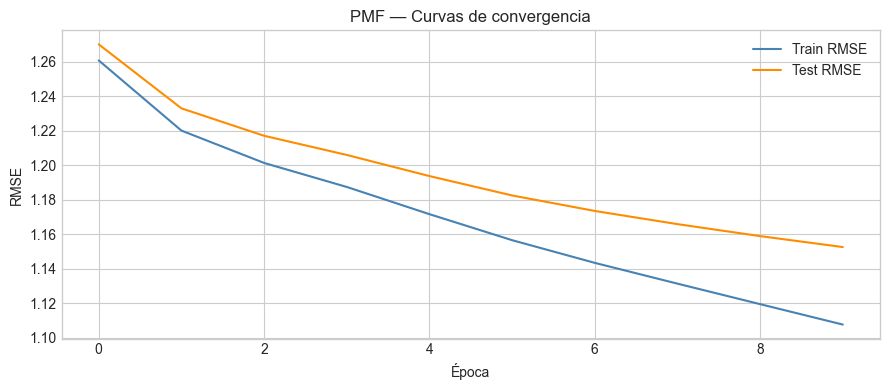

In [ ]:
# Curvas de convergencia
plt.figure(figsize=(9, 4))
plt.plot(history['train_rmse'], label='Train RMSE', color='steelblue')
plt.plot(history['test_rmse'],  label='Test RMSE',  color='darkorange')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.title('PMF — Curvas de convergencia')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Evaluación final con los mejores pesos
final_rmse = compute_rmse_sparse(R_test_sparse, best_P, best_Q, best_bu, best_bi, mu)

# MAE vectorizado
coo_test  = R_test_sparse.tocoo()
r_hat_all = (mu + best_bu[coo_test.row] + best_bi[coo_test.col]
             + (best_P[coo_test.row] * best_Q[coo_test.col]).sum(axis=1))
r_hat_all = np.clip(r_hat_all, R_MIN, R_MAX)
final_mae = float(np.mean(np.abs(coo_test.data - r_hat_all)))

print(f'PMF — Test RMSE: {final_rmse:.4f}')
print(f'PMF — Test MAE : {final_mae:.4f}')
print()
print('=== Comparativa con baseline ===')
display(baseline_results.round(4))

In [ ]:
import pandas as pd
import numpy as np

def generar_resultados_knn(model_knn, matrix_user_item, original_ids_mapping=None, n_neighbors=6):
    """
    Genera un DataFrame con las relaciones Source-Target a partir de un modelo KNN (ej. scikit-learn).
    """
    distances, indices = model_knn.kneighbors(matrix_user_item, n_neighbors=n_neighbors)
    
    resultados = []
    
    # Determinar qué IDs se usan como nodos
    # Si provees original_ids_mapping (dict {indice_matriz: original_id}), úsalo
    if isinstance(matrix_user_item, pd.DataFrame):
        nombres_o_ids = matrix_user_item.index
    elif original_ids_mapping:
        nombres_o_ids = [original_ids_mapping[i] for i in range(matrix_user_item.shape[0])]
    else:
        nombres_o_ids = list(range(matrix_user_item.shape[0]))
    
    for i in range(len(nombres_o_ids)):
        source_anime = nombres_o_ids[i]
        
        # Iterar sobre vecinos ignorando el propio elemento (índice 0 o distancia 0)
        for j in range(1, len(indices[i])):
            target_anime = nombres_o_ids[indices[i][j]]
            distancia = distances[i][j]
            # Dependiendo de tu métrica (cosine vs euclidean) ajusta la similitud. 
            # Aquí asumimos que distancias bajas => mejor.
            similitud = 1 - distancia if distancia <= 1 else 1 / (1 + distancia)
            
            resultados.append({
                'source': source_anime,
                'target': target_anime,
                'distance': distancia,
                'similarity': similitud,
                'rank': j
            })
            
    return pd.DataFrame(resultados)

# ==============================================================================
# EJEMPLO DE USO CON LOS MISMOS DATOS RE-INDEXADOS DEL NOTEBOOK:
# Asumiendo que 'R_train' es tu matriz User-Item o Item-User y quieres KNN por ítem:
#
from sklearn.neighbors import NearestNeighbors
# Para KNN item-item, usamos la matriz transpuesta (items en filas, users en columnas)
item_item_matrix = R_train.transpose()
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(item_item_matrix)

# Extraemos usando el diccionario idx2anime para recuperar IDs verdaderos del dataset
df_knn_results = generar_resultados_knn(knn_model, item_item_matrix, original_ids_mapping=idx2anime, n_neighbors=6)

# Guardamos a CSV. Este archivo debe ser subido al dashboard del frontend (anime-nexus)
df_knn_results.to_csv('resultados_knn.csv', index=False)
print("✅ Resultados KNN exportados correctamente a resultados_knn.csv")
# ==============================================================================

✅ Resultados KNN exportados correctamente a resultados_knn.csv


## Modelo - Híbrido (SVD Colaborativo + TF-IDF Contenido)

In [ ]:
# ---------------------------------------------------------
# 5. MODELO 3 - Híbrido (SVD Colaborativo + TF-IDF Contenido)
# ---------------------------------------------------------
from hybrid import HybridRecommender
import time

# Cargamos el catálogo original con la información pura (RAW IDs)
df_anime = pd.read_csv("data/anime.csv")

print("Inicializando Sistema Híbrido...")
start_time = time.time()

# Pasamos los diccionarios y totales provenientes de mapeos.pkl que ya cargaste arriba
hybrid_model = HybridRecommender(
    df_train=df_train, 
    df_anime=df_anime, 
    num_users=NUM_USERS, 
    num_items=NUM_ITEMS, 
    raw_anime2idx=anime2idx, # Clave para unir el mundo RAW con el mundo procesado
    n_factors=30, 
    alpha=0.7
)

# Entrenamiento conjunto (SVD + Perfiles TF-IDF mediante álgebra lineal rápida)
hybrid_model.fit()
train_time = time.time() - start_time
print(f"Tiempo de entrenamiento: {train_time:.2f} segundos")

print("\n>> Evaluando modelo Híbrido sobre una muestra de Test (2000 registros)...")
df_test_sample = df_test.sample(2000, random_state=42)
hybrid_rmse, hybrid_mae, hybrid_cob, df_hybrid_preds = hybrid_model.evaluate(df_test_sample)

print("="*40)
print(f"🏆 MÉTRICAS DEL MODELO HÍBRIDO 🏆")
print("="*40)
print(f"RMSE (Error Cuadrático) : {hybrid_rmse:.4f}")
print(f"MAE (Error Absoluto)    : {hybrid_mae:.4f}")
print(f"Cobertura               : {hybrid_cob:.2f}%")
print("="*40)

# ==============================================================
# Visualización: Cruzar el ID procesado de vuelta con el ID real
# ==============================================================
print("\n👀 Muestra de Predicciones del Sistema Híbrido:")
muestra_hibrido = df_hybrid_preds.sample(10, random_state=99).copy()
muestra_hibrido['Diferencia_Absoluta'] = abs(muestra_hibrido['rating_real'] - muestra_hibrido['rating_predicho'])

# IMPORTANTE: Revertir el índice interno (0 a N) al ID original de MyAnimeList para cruzar con anime.csv
# El diccionario inverso idx2anime (que creaste o puedes derivar de mapeos) entra en juego:
idx2anime = {idx: anime for anime, idx in anime2idx.items()}
muestra_hibrido['anime_id_raw'] = muestra_hibrido['anime_id'].map(idx2anime)

# Ahora hacemos merge usando el ID original restaurado
muestra_hibrido = muestra_hibrido.merge(
    df_anime[['anime_id', 'name', 'genre']], 
    left_on='anime_id_raw', 
    right_on='anime_id', 
    how='left'
)

# Limpiar las columnas duplicadas y mostrar
columnas_visibles = ['user_id', 'name', 'genre', 'rating_real', 'rating_predicho', 'Diferencia_Absoluta']
display(muestra_hibrido[columnas_visibles].sort_values(by='Diferencia_Absoluta').reset_index(drop=True).style.background_gradient(subset=['Diferencia_Absoluta'], cmap='Reds'))

Inicializando Sistema Híbrido...
>> Inicializando Modelo Híbrido...
   [Contenido] Procesando géneros y tipos de anime con TF-IDF...
>> Entrenando el modelo híbrido...
   [Colaborativo] Factorización SVD sobre matriz dispersa...
   [Contenido] Construyendo perfiles de usuario vía Álgebra Lineal...
✅ ¡Entrenamiento híbrido completado!
Tiempo de entrenamiento: 1.26 segundos

>> Evaluando modelo Híbrido sobre una muestra de Test (2000 registros)...
🏆 MÉTRICAS DEL MODELO HÍBRIDO 🏆
RMSE (Error Cuadrático) : 1.6730
MAE (Error Absoluto)    : 1.3079
Cobertura               : 100.00%

👀 Muestra de Predicciones del Sistema Híbrido:


,user_id,name,genre,rating_real,rating_predicho,Diferencia_Absoluta
0,5883,Nichijou,"Comedy, School, Slice of Life",8,8.550000,0.550000
1,1169,Ookami-san to Shichinin no Nakama-tachi,"Comedy, Parody, Romance",9,8.450000,0.550000
2,39052,Kara no Kyoukai 4: Garan no Dou,"Action, Mystery, Supernatural, Thriller",8,8.900000,0.900000
3,38161,Candy Boy: Nonchalant Talk of the Certain Twin Sisters in Daily Life,"Romance, School, Shoujo Ai",6,7.100000,1.100000
4,13493,Tales of Phantasia The Animation,"Adventure, Fantasy, Shounen",6,7.230000,1.230000
5,2011,Howl no Ugoku Shiro,"Adventure, Drama, Fantasy, Romance",8,9.450000,1.450000
6,8809,Date A Live II,"Comedy, Harem, Mecha, Romance, School, Sci-Fi",7,8.580000,1.580000
7,42986,Akihabara Dennou-gumi,"Adventure, Mecha, Sci-Fi, Shoujo",6,7.670000,1.670000
8,7292,Inferno Cop,"Action, Police",10,7.620000,2.380000
9,4852,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Magic, Military, Shounen",7,9.900000,2.900000
